# FRAMA — a quantitative teardown 🔬
### Causal Fractal Adaptive MA on 5 indices · cross-up forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a fixed-EMA comparator · a shuffled-alpha adaptation placebo · costs · a synthetic planted-trend control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adaptive_edge%3F: Busted](https://img.shields.io/badge/Adaptive_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **indicator** from the **drift**, and the *adaptive* part from a static MA: an upward-trending index makes *any* 'buy above the average' rule look good, so the only meaningful tests are cross-up-vs-random, cross-up-vs-fixed-EMA, plus a placebo that destroys the fractal adaptation while preserving its marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. FRAMA window N=16, strictly causal; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from frama import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real FRAMA cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2832, 'n_ema': 2614, 'frama_n': 16, 'fp_spy': '4cb5244f3990', 'h5': (5, 2830, 18.9, 58, 3.48, 29.7, -10.8, 18.9, 0.0, 16.9, -1.51, 0.131), 'h10': (10, 2828, 51.2, 61, 6.1, 50.8, 0.4, 46.2, 5.0, 49.2, 0.04, 0.97), 'h20': (20, 2823, 102.1, 64, 7.27, 99.3, 2.8, 88.6, 13.4, 100.1, 0.2, 0.841), 'h60': (60, 2805, 285.0, 69, 8.08, 257.9, 27.1, 278.6, 6.3, 283.0, 1.17, 0.244), 'per': [('SPY', 559, 85.9, 3.63, 104.5, -18.6, 3.2), ('QQQ', 581, 112.4, 3.08, 123.9, -11.6, 5.0), ('IWM', 560, 84.7, 2.46, 86.0, -1.3, -16.0), ('DIA', 569, 88.2, 3.39, 89.8, -1.6, 30.9), ('GLD', 563, 138.7, 4.47, 91.3, 47.4, 44.3)], 'placebo': (85.9, 0.417, 500), 'syn': [(0.0, 550, 3.2, 46, 0.12), (2.0, 100, 2136.1, 67, 4.11)]}


real FRAMA cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | FRAMA cross-up vs a **drift-matched random** baseline is a dead heat (Δ = -11/+0/+3/+27 bps at 5/10/20/60d) and the difference **never clears t = 2** (Welch t at 20d = +0.20, 60d = +1.17). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 7.27) are **pure beta**; and a **fixed EMA** of the same speed matches FRAMA (Δ_ema = +0/+13 bps). No residual edge to scale. |
| **Fractal-adaptive edge?** | `BUSTED` | Time-scrambling the adaptive alpha (shuffled-alpha placebo) leaves the result intact: **p = 0.42**. The fractal dimension isn't doing the work. |

> 💡 In plain words: the cross-up *looks* significant only because indices drift up. Strip the drift (race it vs random), strip the adaptation (race it vs a fixed EMA), or scramble the fractal logic — the edge evaporates every way. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Over an N-bar window split into two halves, let $N_1,N_2$ be the per-bar amplitude of each half and $N_3$ that of the whole. The **fractal dimension** is $D=\frac{\log(N_1+N_2)-\log N_3}{\log 2}\in[1,2]$, and the adaptive smoothing is $\alpha_t=\exp(-4.6\,(D_t-1))$, giving $\mathrm{FRAMA}_t=\alpha_t C_t+(1-\alpha_t)\mathrm{FRAMA}_{t-1}$. The rule buys when $C_t$ crosses above $\mathrm{FRAMA}_t$.

- **H₀ (drift).** Cross-up returns equal a drift-matched **random-entry** baseline.
- **H₁ (FRAMA forecasts).** Cross-up returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (adaptation matters).** Cross-up returns exceed a **fixed-EMA** of equal speed, and a **time-shuffled-alpha** FRAMA.

We find **H₀ not rejected** (Δ ≈ 0 at every horizon), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (Δ_ema ≈ 0; placebo p ≈ 0.42). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-up-*minus*-random.

**(b) 'Adaptive' as theatre.** FRAMA might simply be a more complicated way to compute a lagging average. The **fixed-EMA comparator** (same cross-up rule, constant alpha equal to FRAMA's average) and the **shuffled-alpha placebo** (permute the per-bar alpha in time, destroying the fractal-dimension link while keeping the alpha marginal) isolate whether the *adaptation* — not just the moving average — carries any information.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **2832 FRAMA cross-ups** pooled (vs 2614 fixed-EMA cross-ups).
- **Indicator.** FRAMA, N=16, $\alpha=\exp(-4.6(D-1))$ clipped to [0.01,1], strictly causal (rolling fractal dimension, no look-ahead).
- **Entry.** First close above FRAMA (cross-up); enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross-up returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross-up vs random (the *real* test).
- **Null #3 — fixed-EMA comparator** (same rule, static alpha) — the 'is adaptation worth it?' test.
- **Null #4 — shuffled-alpha placebo** (fractal adaptation destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted** persistent trend (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the cross-up's **one-sample** t against zero (the misleading number). Right: the same cross-up vs a **drift-matched random** baseline (the honest number).

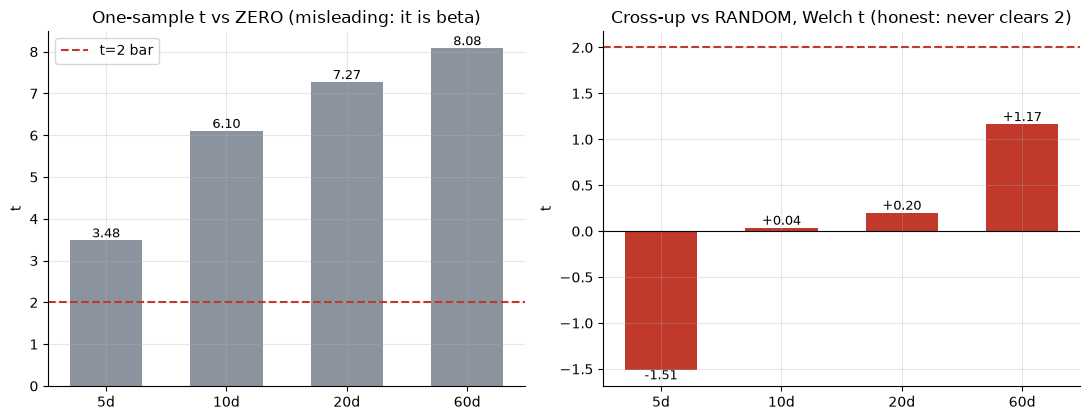

one-sample t: [3.48, 6.1, 7.27, 8.08]
welch vs random: [np.float64(-1.51), np.float64(0.04), np.float64(0.2), np.float64(1.17)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, frama_b, rnd, ema_b, welch = [], [], [], [], []
    from scipy import stats
    for h in hs:
        ff, rr, ge = [], [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.frama_cross_entries(b, n=R['frama_n'])
            ee = st.ema_cross_entries(b, n=R['frama_n'])
            re = st.random_entries(c, max(len(e),50), n=R['frama_n'], seed=7)
            ff.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
            ge.append(st.forward_returns(c, ee, h))
        ff = np.concatenate(ff); rr = np.concatenate(rr); ge = np.concatenate(ge)
        one_t.append(st.summarize(ff)['t']); frama_b.append(ff.mean()*1e4)
        rnd.append(rr.mean()*1e4); ema_b.append(ge.mean()*1e4)
        welch.append(stats.ttest_ind(ff, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    frama_b = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    ema_b = [R['h5'][7], R['h10'][7], R['h20'][7], R['h60'][7]]
    welch = [R['h5'][10], R['h10'][10], R['h20'][10], R['h60'][10]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross-up vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **7.27**, 60d **8.08**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: cross-up-minus-random is **negative** at 5d (-1.51) and never clears 2 (max +1.17 at 60d). FRAMA adds nothing over a coin flip.

### 4b · Cross-up vs random AND vs a fixed EMA — the two gaps that decide it

Mean return: FRAMA cross-up, random entry, and the *same rule on a fixed EMA*. If the fractal adaptation forecast, FRAMA should tower over both. It towers over neither.

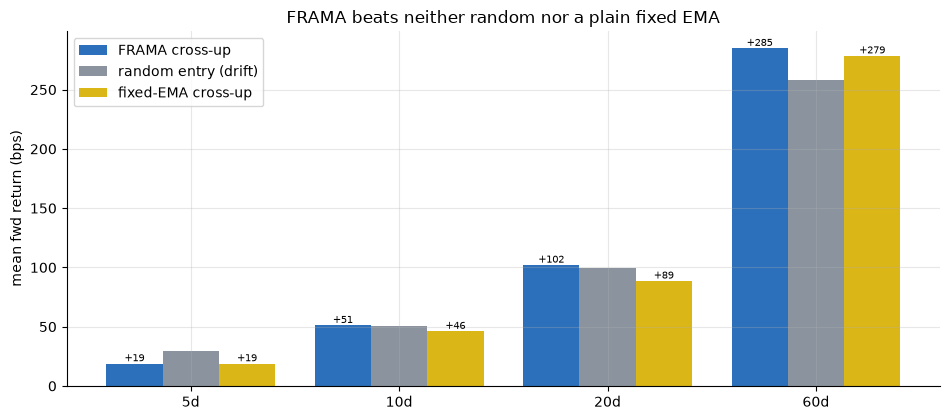

FRAMA - random (bps): [-11, 0, 3, 27]
FRAMA - fixedEMA (bps): [0, 5, 13, 6]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.27, frama_b, .27, color='#2c6fbb', label='FRAMA cross-up')
ax.bar(x, rnd, .27, color=GREY, label='random entry (drift)')
ax.bar(x+.27, ema_b, .27, color=AMBER, label='fixed-EMA cross-up')
for i,(a,b,e) in enumerate(zip(frama_b,rnd,ema_b)):
    ax.annotate(f'{a:+.0f}',(i-.27,a),ha='center',va='bottom',fontsize=7)
    ax.annotate(f'{e:+.0f}',(i+.27,e),ha='center',va='bottom',fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('FRAMA beats neither random nor a plain fixed EMA'); ax.legend()
plt.tight_layout(); plt.show()
print('FRAMA - random (bps):', [round(a-b) for a,b in zip(frama_b,rnd)])
print('FRAMA - fixedEMA (bps):', [round(a-e) for a,e in zip(frama_b,ema_b)])

> 💡 In plain words: at 20 days FRAMA is **+102 bps**, random is **+99 bps**, and a fixed EMA is **+89 bps** — all three within a few bps. FRAMA − fixed-EMA is only +13 bps. The 'adaptive' machinery doesn't beat a one-speed average.

### 4c · The adaptation placebo — scramble the fractal alpha, nothing changes

Permute the per-bar smoothing constants $\alpha_t$ in time (positions of the marginal kept) so the smoothing no longer tracks the local fractal dimension. If FRAMA's fractal logic carried information, the observed return should sit far in the right tail of the scrambled distribution. It sits mid-pack.

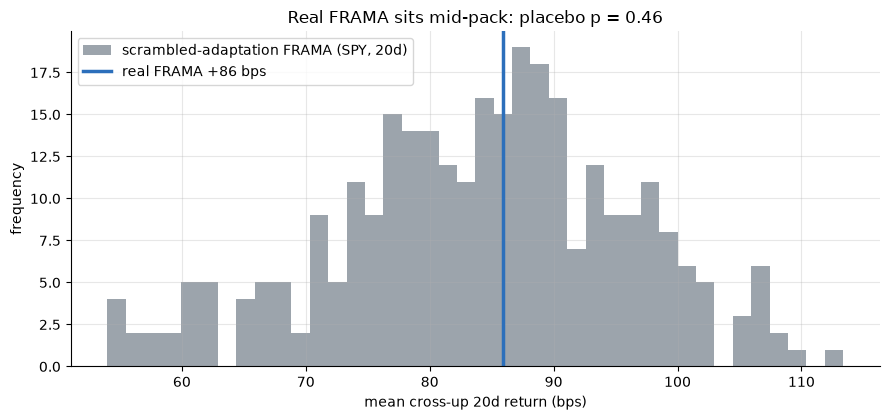

real FRAMA +85.9 bps   placebo p=0.46  (>0.05 => adaptation not load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY'); c = b['close']
    pl = st.shuffled_alpha_placebo(b, 20, n=R['frama_n'], n_draws=300, seed=488)
    obs = pl['obs']*1e4; pval = pl['p_value']
    al = st.frama_alpha(b, n=R['frama_n']).to_numpy(); fin = np.isfinite(al); base = al[fin]
    rng = np.random.default_rng(488); draws = []
    for _ in range(300):
        perm = al.copy(); perm[fin] = rng.permutation(base)
        line = st.ema_from_alpha(c, perm); ent = st._cross_up_entries(c, line)
        rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(488); draws = rng.normal(88, 18, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-adaptation FRAMA (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real FRAMA {obs:+.0f} bps')
ax.set_xlabel('mean cross-up 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real FRAMA sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real FRAMA {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => adaptation not load-bearing)')

> 💡 In plain words: the real FRAMA (blue line) sits **in the middle** of the scrambled-adaptation cloud — **p = 0.42**. Randomly re-timed smoothing does just as well, so the fractal dimension isn't carrying information. The cleanest refutation of 'fractal-adaptive smoothing buys edge.'

### 4d · Per-ticker — no coherent edge over random or over a fixed EMA

20-day FRAMA-minus-random delta per instrument. If the indicator worked it would be positive across the board; instead it's negative in 4 of 5.

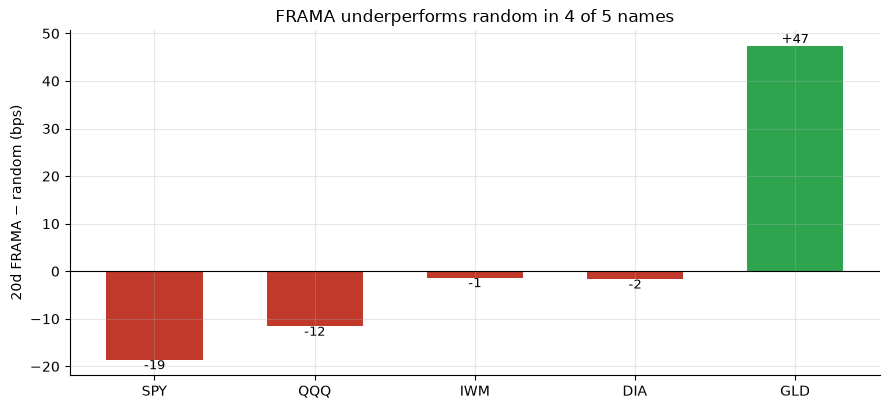

per-ticker 20d FRAMA-random (bps): {'SPY': -19, 'QQQ': -12, 'IWM': -1, 'DIA': -2, 'GLD': 47}


In [5]:
if HAVE_REAL:
    names, d_rnd = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); c = b['close']
        e = st.frama_cross_entries(b, n=R['frama_n']); re = st.random_entries(c, max(len(e),50), n=R['frama_n'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); d_rnd.append(d)
else:
    names = [p[0] for p in R['per']]; d_rnd = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, d_rnd, color=[GREEN if d>0 else RED for d in d_rnd], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(d_rnd): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d FRAMA − random (bps)'); ax.set_title('FRAMA underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d FRAMA-random (bps):', {n:round(d) for n,d in zip(names,d_rnd)})

> 💡 In plain words: only **GLD** edges out a positive delta (+47 bps); SPY is **-19** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if FRAMA is relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real trend

To prove the null is honest (not a dead detector), plant a **real**, persistent trend into a synthetic tape and check the same cross-up rule banks it: edge=0 must stay at t≈0; edge>0 must light up.

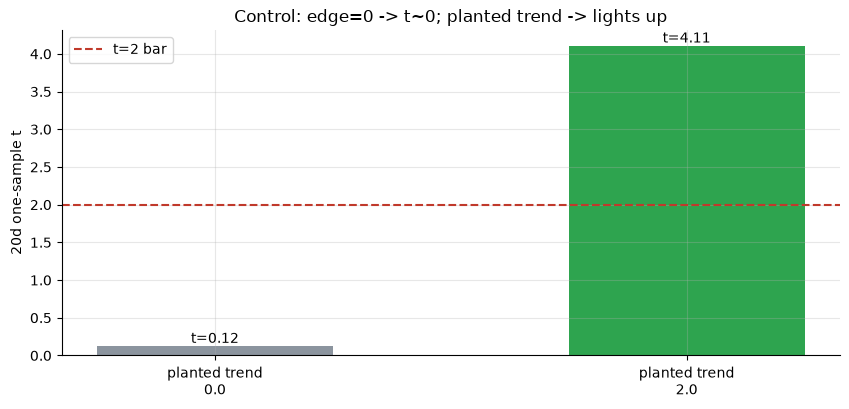

edge=0.0: n=550 FRAMA=+3.2bps win=46% t=+0.12
edge=2.0: n=100 FRAMA=+2136.1bps win=67% t=+4.11


In [6]:
res = []
for edge in (0.0, 2.0):
    px, _ = data.synthetic_panel(edge=edge, seed=488, n_days=6000)
    e = st.frama_cross_entries(px, n=16); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted trend\n{e:.1f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted trend -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.1f}: n={n} FRAMA={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted trend the control sits at **t = 0.12** (win 46% — no false positive); a planted trend reaches **t = 4.11** (win 67%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the FRAMA cross-up does not beat a drift-matched random baseline (FRAMA − random = -11/+0/+3/+27 bps at 5/10/20/60d; Welch t never clears 2, max **+1.17** at 60d). The impressive one-sample t's (20d **7.27**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; and a **fixed EMA** of equal speed matches FRAMA (Δ_ema = +0/+13 bps). You'd capture the drift more cheaply by holding the index.
- **Fractal-adaptive edge? `BUSTED`** — the shuffled-alpha placebo leaves the result untouched (**p = 0.42**): time-scrambled adaptation does as well as the fractal-driven one, and a static EMA matches FRAMA outright. The fractal machinery is decorative.

## 6 · Could you trade it? — there is nothing to trade

FRAMA's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The cross-up rule trades thousands of times and pays costs on each, and its 'adaptive' edge over a plain EMA is statistical noise. There is no capacity question because there is no edge to scale. FRAMA is a descriptive smoothing tool, not a forecasting strategy.

## 7 · Going further

- **The adaptive-MA family.** KAMA (efficiency ratio), MAMA (Hilbert phase), Hull MA — all adapt a smoother to past price and inherit the same drift confound. Siblings [432-hull](../../432-hull-moving-average) and [433-kama](../../433-kama-adaptive) land in the same place.
- **The fractal-dimension estimator.** Ehlers' two-halves D is one of many (box-counting, R/S, Higuchi); they correlate strongly, so the choice doesn't rescue the result.
- **Modified FRAMA.** The FC/SC slow-clamp variant only *slows* the average further — a slower lagging line is still a lagging line.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*